# Model Evaluation and Explainability

This notebook evaluates trained models for audio deepfake detection and provides explainability using Grad-CAM.

Key components:
- Model comparison (CNN, Dropout, Attention)
- Equal Error Rate (EER) evaluation
- Grad-CAM visualization
- Text-based explanations
- Report generation for user interface integration

## 1. Import Libraries

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import librosa
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
import random

from src.models import CNN, CNN_Dropout, CNN_Attention

## 2. Configuration

In [2]:
DATA_PATH = "../data/ASVspoof2019_LA/ASVspoof2019_LA_train/flac"

SR = 16000
DURATION = 3
IMG_SIZE = 128

## 3. Device Setup

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## 4. Load Trained Models

In [4]:
cnn = CNN().to(device)
cnn.load_state_dict(torch.load("../models/cnn.pth"))

drop = CNN_Dropout().to(device)
drop.load_state_dict(torch.load("../models/cnn_dropout.pth"))

attn = CNN_Attention().to(device)
attn.load_state_dict(torch.load("../models/cnn_attention.pth"))

cnn.eval()
drop.eval()
attn.eval()

CNN_Attention(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (attention): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

## 5. Audio Preprocessing

In [5]:
def audio_to_mel(path):
    y, _ = librosa.load(path, sr=SR)

    max_len = SR * DURATION
    y = y[:max_len] if len(y) > max_len else np.pad(y, (0, max_len - len(y)))

    mel = librosa.feature.melspectrogram(y=y, sr=SR)
    mel = librosa.power_to_db(mel, ref=np.max)

    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    mel = cv2.resize(mel, (IMG_SIZE, IMG_SIZE))

    return mel

## 6. Grad-CAM Explainability

In [6]:
def generate_gradcam(model, input_tensor, target_class):
    model.eval()

    input_tensor = input_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    output = model(input_tensor, explain=True)

    model.zero_grad()
    output[0, target_class].backward()

    gradients = model.gradients
    activations = model.feature_maps

    weights = gradients.mean(dim=(2,3), keepdim=True)
    cam = (weights * activations).sum(dim=1).squeeze()

    cam = torch.relu(cam).detach().cpu().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    return cam

## 7. Prediction Function

In [7]:
def predict(model, audio_path):
    mel = audio_to_mel(audio_path)

    tensor = torch.tensor(mel, dtype=torch.float32)\
        .unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)

    pred = torch.argmax(probs).item()
    confidence = probs[0][pred].item()

    if hasattr(model, "feature_maps"):
        cam = generate_gradcam(model, tensor.squeeze(0), pred)
    else:
        cam = None

    return mel, pred, confidence, probs.detach().cpu().numpy(), cam

## 8. Explainability

In [8]:
def generate_gradcam(model, input_tensor, target_class):
    model.eval()

    input_tensor = input_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    output = model(input_tensor, explain=True)

    model.zero_grad()
    output[0, target_class].backward()

    gradients = model.gradients
    activations = model.feature_maps

    # Safety check
    if gradients is None:
        raise ValueError("Gradients not captured. Check hooks.")

    weights = gradients.mean(dim=(2,3), keepdim=True)
    cam = (weights * activations).sum(dim=1).squeeze()

    cam = torch.relu(cam).detach().cpu().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    return cam

## 9. Explanation Summary

In [9]:
def explanation_summary(cam, pred):
    stats = analyze_cam(cam)

    summary = []

    if stats["high"] > stats["low"]:
        summary.append("✔ Strong high-frequency activation")
    else:
        summary.append("✔ Dominant low-frequency structure")

    if stats["temporal_var"] > 0.15:
        summary.append("✔ High temporal instability")
    else:
        summary.append("✔ Stable temporal patterns")

    if pred == 1:
        summary.append("✔ Matches synthetic speech characteristics")
    else:
        summary.append("✔ Matches natural speech characteristics")

    return summary

## 10. Visualization

In [10]:
def visualize(mel, cam):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Spectrogram")
    plt.imshow(mel, origin='lower')

    plt.subplot(1,2,2)
    plt.title("Grad-CAM")

    if cam is not None:
        plt.imshow(mel, cmap='gray', origin='lower')
        plt.imshow(cam, cmap='jet', alpha=0.5)
    else:
        plt.text(0.3, 0.5, "Grad-CAM not available", fontsize=12)

    plt.show()

## 11. Test on Random Sample

In [11]:
def analyze_cam(cam):
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    h, w = cam.shape

    # Split into regions
    low_freq = cam[:h//3, :]
    mid_freq = cam[h//3:2*h//3, :]
    high_freq = cam[2*h//3:, :]

    # Energy in each band
    low_energy = np.mean(low_freq)
    mid_energy = np.mean(mid_freq)
    high_energy = np.mean(high_freq)

    # Temporal variation (captures instability)
    temporal_variation = np.std(np.mean(cam, axis=0))

    return {
        "low": low_energy,
        "mid": mid_energy,
        "high": high_energy,
        "temporal_var": temporal_variation
    }

In [12]:
def generate_explanation(cam, pred, confidence):
    stats = analyze_cam(cam)

    explanation = ""

    # Confidence interpretation
    if confidence > 0.9:
        explanation += "The model is highly confident in its decision. "
    elif confidence > 0.75:
        explanation += "The model is moderately confident. "
    else:
        explanation += "The model has low confidence, indicating uncertainty. "

    # Detailed reasoning
    if pred == 1:  # FAKE
        explanation += "The prediction indicates synthetic speech because "

        if stats["high"] > stats["low"]:
            explanation += (
                "the model focuses heavily on high-frequency regions. "
                "These regions often contain artifacts introduced by speech synthesis models, "
                "such as unnatural harmonics and sharp spectral inconsistencies. "
            )

        if stats["temporal_var"] > 0.15:
            explanation += (
                "Additionally, the temporal variation is high, suggesting instability across time, "
                "which is a known characteristic of generated audio."
            )
        else:
            explanation += (
                "The spectral structure lacks smooth continuity, which is atypical for natural speech."
            )

    else:  # REAL
        explanation += "The prediction indicates natural human speech because "

        if stats["low"] > stats["high"]:
            explanation += (
                "the model focuses more on low-frequency bands, "
                "which correspond to fundamental speech components and are typically stable in real audio. "
            )

        if stats["temporal_var"] < 0.1:
            explanation += (
                "The temporal consistency is high, indicating smooth transitions over time, "
                "a hallmark of genuine human speech."
            )
        else:
            explanation += (
                "The spectral distribution remains balanced without sharp irregularities, "
                "supporting a real speech classification."
            )

    return explanation

Testing file: ../data/ASVspoof2019_LA/ASVspoof2019_LA_train/flac/LA_T_9004526.flac

Prediction: Fake
Confidence: 100.0 %

Probabilities:
Real: 0.0 %
Fake: 100.0 %

Explanation:
The model is highly confident in its decision. The prediction indicates synthetic speech because The spectral structure lacks smooth continuity, which is atypical for natural speech.

Summary:
✔ Dominant low-frequency structure
✔ Stable temporal patterns
✔ Matches synthetic speech characteristics


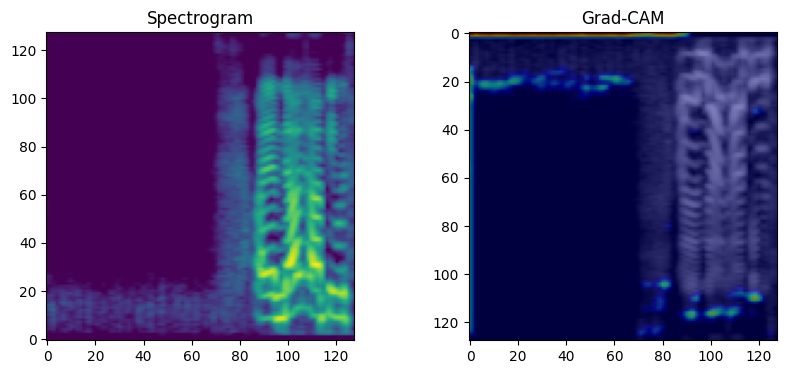

In [13]:
files = os.listdir(DATA_PATH)
audio_path = os.path.join(DATA_PATH, random.choice(files))

print("Testing file:", audio_path)

mel, pred, conf, probs, cam = predict(attn, audio_path)

print("\nPrediction:", "Fake" if pred else "Real")
print("Confidence:", round(conf * 100, 2), "%")

print("\nProbabilities:")
print("Real:", round(probs[0][0]*100,2), "%")
print("Fake:", round(probs[0][1]*100,2), "%")

print("\nExplanation:")
print(generate_explanation(cam, pred, conf))

print("\nSummary:")
for s in explanation_summary(cam, pred):
    print(s)

visualize(mel, cam)

## 12. Model Comparison

In [14]:
for model, name in [(cnn,"CNN"), (drop,"Dropout"), (attn,"Attention")]:
    _, pred, conf, _, cam = predict(model, audio_path)

    print(f"{name}: {'Fake' if pred else 'Real'} ({conf:.2f})")

    if cam is None:
        print("   → No explainability (baseline model)")
    else:
        print("   → Grad-CAM explanation available")

CNN: Fake (1.00)
   → No explainability (baseline model)
Dropout: Fake (1.00)
   → No explainability (baseline model)
Attention: Fake (1.00)
   → Grad-CAM explanation available
